In [2]:
import salem
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import glob
import os

In [1]:
cd ..

/users/global/cornkle/pythonWorkspace


In [12]:
era_root = '/prj/global_water/ERA5/hourly/surface/SAf/'
months = [11, 12, 1, 2]

files = sorted(glob.glob(era_root + 'ERA5_2019*_SAf_srfc.nc'))

def month_from_fname(fname):
    parts = os.path.basename(fname).split('_')
    return int(parts[2])

selected = [f for f in files if month_from_fname(f) in months]

dsraw = xr.open_mfdataset(selected, combine='by_coords')

In [13]:
era_root = '/prj/global_water/ERA5/hourly/pressure_levels/SAf/'
files = sorted(glob.glob(era_root + 'ERA5_2019*_SAf_pl.nc'))

def month_from_fname(fname):
    parts = os.path.basename(fname).split('_')
    return int(parts[2])

selected = [f for f in files if month_from_fname(f) in months]

ds_plraw = xr.open_mfdataset(selected, combine='by_coords')

In [31]:
hours = np.arange(12,16)
ds = dsraw.where(dsraw.time.dt.hour.isin(hours), drop=True).mean('time')
ds_pl = ds_plraw.where(ds_plraw.time.dt.hour.isin(hours), drop=True).mean('time')

In [32]:
ds = ds.load()
ds_pl = ds_pl.load()

In [33]:
topo = '/prj/global_water/ERA5_global_0.7/static/era5_invariant_025deg.nc'
topods = xr.open_dataset(topo)['z']
theight = (topods / 9.80665).squeeze()

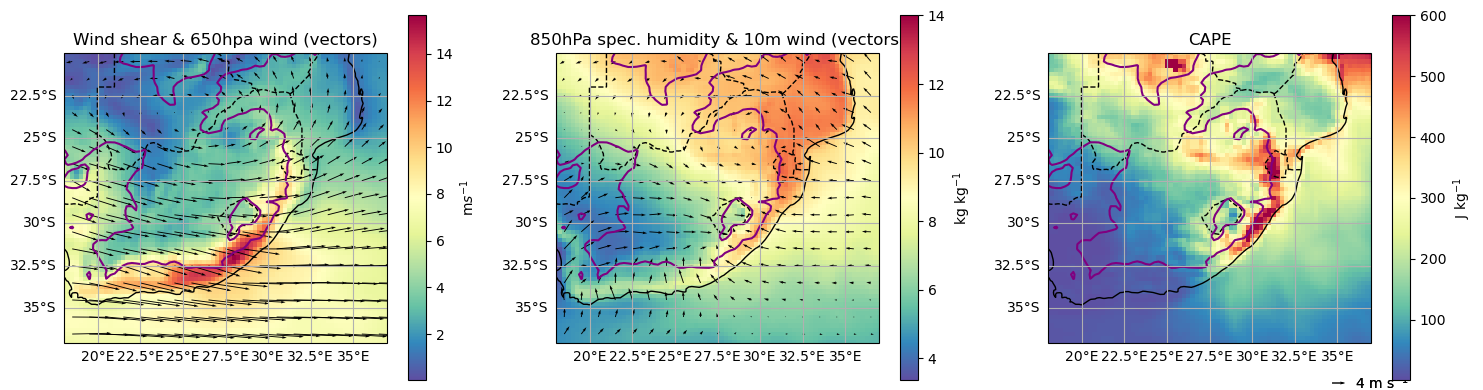

In [36]:
fig = plt.figure(figsize=(15, 4))

ax = fig.add_subplot(1, 3, 1, projection=ccrs.PlateCarree())

st=4
sarrow = 2
xquiv = ds.longitude[sarrow::st]
yquiv = ds.latitude[sarrow::st]

uu = (ds_pl.u.sel(level=650).values)[sarrow::st, sarrow::st]
vv = (ds_pl.v.sel(level=650).values)[sarrow::st, sarrow::st]

quiver = {'x' : xquiv, 'y' : yquiv, 'u' : uu, 'v' : vv, 'scale' : 100}

ws = np.sqrt(ds_pl.u.sel(level=850).values**2 + ds_pl.v.sel(level=850).values**2)

du = ds_pl.u.sel(level=650).values - ds_pl.u.sel(level=850).values
dv = ds_pl.v.sel(level=650).values - ds_pl.v.sel(level=850).values
shear_mag = (du**2 + dv**2)**0.5

mesh = ax.pcolormesh(ds.longitude,ds.latitude,shear_mag, transform=ccrs.PlateCarree(), cmap='Spectral_r')
c = ax.contour(topods.longitude,topods.latitude,theight, transform=ccrs.PlateCarree(), colors='purple', linewidths=1.5, levels=[1000,2000])

qu = ax.quiver(quiver['x'], quiver['y'], quiver['u'], quiver['v'], scale=quiver['scale'])
qk = plt.quiverkey(qu, 0.9, 0.03, 4, '4 m s$^{-1}$',
                    labelpos='E', coordinates='figure')

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle='--', edgecolor='black')
ax.set_ylim(-37, -20)
ax.set_xlim(18,37)
plt.title('Wind shear & 650hpa wind (vectors)')

gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = True
gl.left_labels = True

plt.colorbar(mesh, ax=ax, label='m$ s^{-1}$')

################

uu = (ds.u10.values)[sarrow::st, sarrow::st]
vv = (ds.v10.values)[sarrow::st, sarrow::st]

quiver = {'x' : xquiv, 'y' : yquiv, 'u' : uu, 'v' : vv, 'scale' : 100}

ax = fig.add_subplot(1, 3, 2, projection=ccrs.PlateCarree())

mesh = ax.pcolormesh(ds.longitude,ds.latitude,ds_pl.q.sel(level=850)*1000, transform=ccrs.PlateCarree(), cmap='Spectral_r', vmax=14)
ax.contour(topods.longitude,topods.latitude,theight, transform=ccrs.PlateCarree(), colors='purple', linewidths=1.5, levels=[1000,2000])
qu = ax.quiver(quiver['x'], quiver['y'], quiver['u'], quiver['v'], scale=quiver['scale'])
qk = plt.quiverkey(qu, 0.9, 0.03, 4, '4 m s$^{-1}$',
                    labelpos='E', coordinates='figure')

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle='--', edgecolor='black')
ax.set_ylim(-37, -20)
ax.set_xlim(18,37)

gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = True
gl.left_labels = True

plt.colorbar(mesh, ax=ax, label='kg kg$^{-1}$')
plt.title('850hPa spec. humidity & 10m wind (vectors)')

######################################

ax = fig.add_subplot(1, 3, 3, projection=ccrs.PlateCarree())

mesh = ax.pcolormesh(ds.longitude,ds.latitude,ds.cape, transform=ccrs.PlateCarree(), cmap='Spectral_r', vmax=600)
ax.contour(topods.longitude,topods.latitude,theight, transform=ccrs.PlateCarree(), colors='purple', linewidths=1.5, levels=[1000,2000])

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle='--', edgecolor='black')
ax.set_ylim(-37, -20)
ax.set_xlim(18,37)

gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = True
gl.left_labels = True
plt.title('CAPE')

plt.colorbar(mesh, ax=ax, label='J kg$^{-1}$')

plt.tight_layout()
plt.show()
fig.savefig('/users/global/cornkle/shared/figs/MCS_SAf/ERA5_SA_variables.png', dpi=300)

In [ ]:
fig = plt.figure(figsize=(8, 6))

# Choose a map projection, could be any projection you like
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([18, 37, -35, -20], crs=ccrs.PlateCarree())
mesh = ax.contourf(topods.longitude,topods.latitude,theight, transform=ccrs.PlateCarree(), levels=np.arange(5, 3000, 250), cmap='terrain')

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle='--')



# Some extra lines if you want
ax.gridlines(draw_labels=True)

plt.colorbar(mesh, ax=ax)
plt.show()

In [ ]:
## a clean way of plotting - use matplotlib functions directly:

def draw_map_wind(ax, data, lon, lat, title=None,  mask_sig=None, quiver=None, contour=None, cbar_label=None, **kwargs):

    mapp = ax.contourf(lon, lat, data, transform=ccrs.PlateCarree(), **kwargs)  # this is the actual plot
    
    ## mask for significance indicator
    if mask_sig is not None:
         plt.contourf(lon, lat, mask_sig, colors='none', hatches='.',
                     levels=[0.5, 1], linewidth=0.1)
    
    ## quiver list
    if quiver is not None:
        qu = ax.quiver(quiver['x'], quiver['y'], quiver['u'], quiver['v'], scale=quiver['scale'])
        qk = plt.quiverkey(qu, 0.9, 0.03, 4, '4 m s$^{-1}$',
                           labelpos='E', coordinates='figure')
        
    ## additional contour on plot   
    if contour is not None:
        ax.contour(contour['x'], contour['y'], contour['data'], levels=contour['levels'], cmap=contour['cmap'] )
        
    
    ax.coastlines()   ## adds coastlines
    # Gridlines
    xl = ax.gridlines(draw_labels=True);   # adds latlon grid lines
    xl.xlabels_top = False   ## labels off
    xl.ylabels_right = False
    plt.title(title)
    # Countries
    ax.add_feature(cartopy.feature.BORDERS, linestyle='--'); # adds country borders
    cbar = plt.colorbar(mapp)  # adds colorbar
    cbar.set_label(cbar_label)
    plt.tight_layout()
    #plt.savefig('/home/ck/DIR/cornkle/figs/HUARAZ/conny_examples/850hpa_rh_ERA5_peru.png')

In [ ]:
import ipdb
f = plt.figure(figsize=(10,6), dpi=200)
for hids, h in enumerate(monthlyclim.hour.values):
    ax = f.add_subplot(3,3,hids+1, projection=ccrs.PlateCarree())
    # preparation of wind vector data in plot
    st=4
    sarrow = 2
    xquiv = monthlyclim.longitude[sarrow::st]
    yquiv = monthlyclim.latitude[sarrow::st]
    
    shour = monthlyclim.sel(hour=h)

    uu = (shour['u10'].values)[sarrow::st, sarrow::st]
    vv = (shour['v10'].values)[sarrow::st, sarrow::st]

    qin = {'x' : xquiv, 'y' : yquiv, 'u' : uu, 'v' : vv, 'scale' : 150}
    
    lon = shour.longitude
    lat = shour.latitude
    #ipdb.set_trace()
    draw_map_wind(ax, shour['v10'], shour.longitude, shour.latitude, title='August 2000 | hour: '+str(h),  quiver=qin, cbar_label='', cmap='RdBu', levels=np.arange(-5,5, 0.5), extend='both')

In [ ]:
monthlyclim['v10'].sel(hour=0).plot.contourf()

In [ ]:
lp = monthlyclim.mean(['latitude', 'longitude'])

In [ ]:
lp

In [ ]:
plt.plot(lp.month.values, lp['tp'], '-ko')